# Graph comparison across embeddings
Author: 

In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np


### Explore : which embedding correspond to now existing KNN (obsp/distances, obsp/connectivities )

In [4]:
adata = ad.read_zarr("data/retina_ganglion_ex_midget_preprocessed.zarr")
adata.uns["neighbors"]["params"]

{'method': 'umap',
 'metric': 'euclidean',
 'n_neighbors': 15,
 'random_state': 0,
 'use_rep': 'X_pca'}

PCA neighbors already exists, great 

### Check if existing umap has recorded seeds

In [5]:
adata.obsm_keys()

['X_pca', 'X_scVI', 'X_umap', 'X_umap_scvi']

In [6]:
adata.uns["umap"].get("params", {})

{'a': 0.5830300205483709, 'b': 1.334166992455648}

In [7]:
adata.uns.get("umap_scvi", {})

{}

can't be very sure

### Try to generate 2 UMAP of 2 seeds and store their parameters via key_added
1) for PCA neighbors

In [8]:
# make sure we're using PCA neighbors 
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15, metric="euclidean", key_added="pca")

In [9]:
# UMAP seed 0
sc.tl.umap(adata, neighbors_key="pca", random_state=0)
adata.obsm["X_umap_seed0"] = adata.obsm["X_umap"].copy()
adata.uns["umap_seed0"] = adata.uns["umap"].copy()

In [10]:
# UMAP seed 1
sc.tl.umap(adata, neighbors_key="pca", random_state=1)
adata.obsm["X_umap_seed1"] = adata.obsm["X_umap"].copy()
adata.uns["umap_seed1"] = adata.uns["umap"].copy()

In [11]:
[k for k in adata.obsm.keys() if "umap" in k.lower()]

['X_umap', 'X_umap_scvi', 'X_umap_seed0', 'X_umap_seed1']

In [12]:
print("seed0 shape:", adata.obsm["X_umap_seed0"].shape)
print("seed1 shape:", adata.obsm["X_umap_seed1"].shape)

seed0 shape: (20587, 2)
seed1 shape: (20587, 2)


In [19]:
adata.uns["umap_seed0"]

{'params': {'a': 0.5830300205483709, 'b': 1.334166992455648}}

quite normal cuz seed = 0 usually as default so not displaying

In [18]:
adata.uns["umap_seed1"]

{'params': {'a': 0.5830300205483709,
  'b': 1.334166992455648,
  'random_state': 1}}

To check if 2 seeds really generated different umap data

In [ ]:
np.max(np.abs(adata.obsm["X_umap_seed0"] - adata.obsm["X_umap_seed1"]))

23.061329

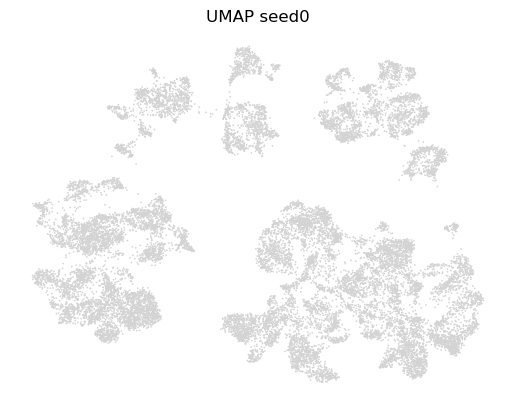

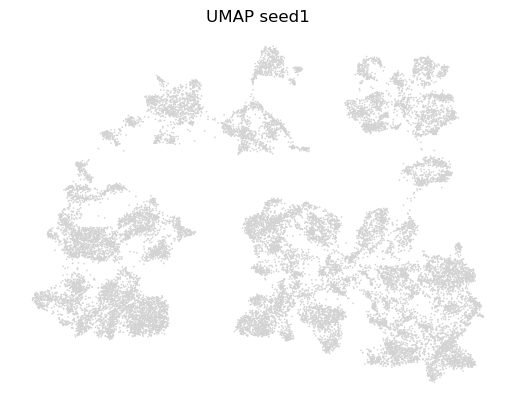

In [ ]:
sc.pl.embedding(adata, basis="umap_seed0", frameon=False,title="UMAP seed0")
sc.pl.embedding(adata, basis="umap_seed1", frameon=False,title="UMAP seed1")

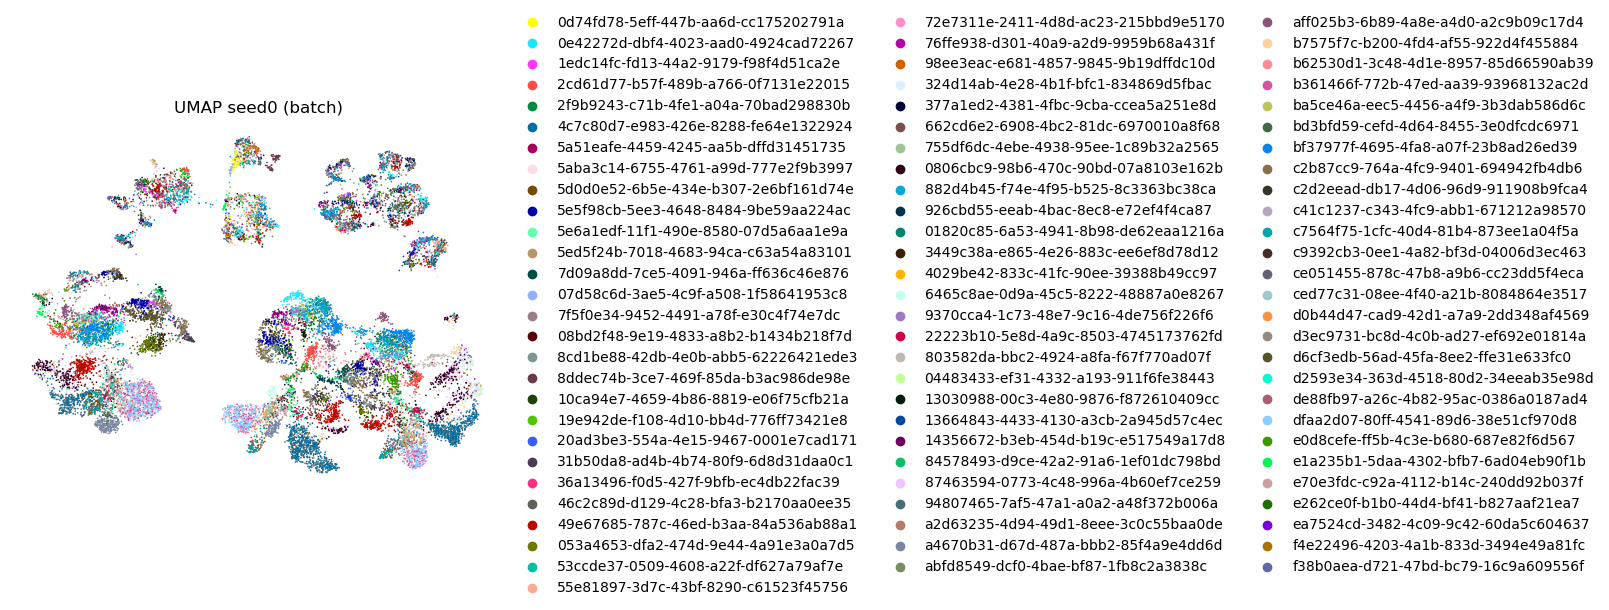

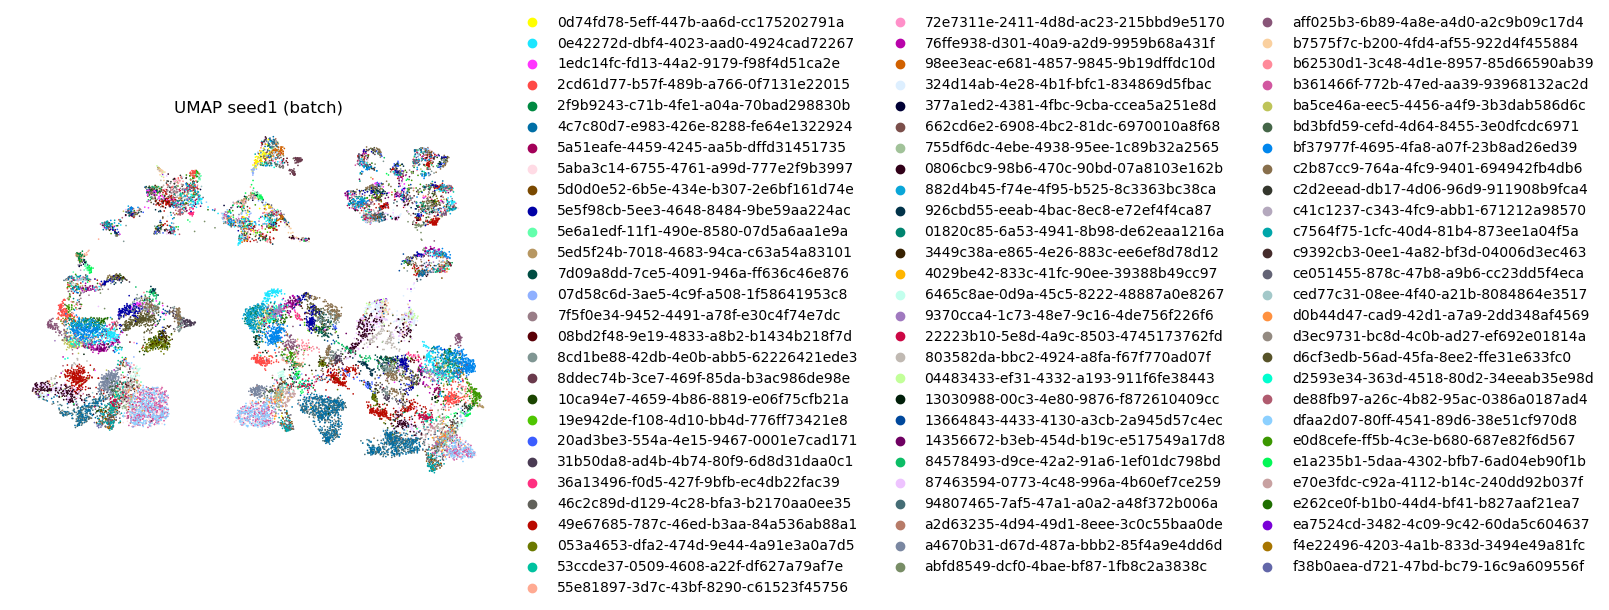

In [23]:
sc.pl.embedding(adata, basis="umap_seed0", color="library_id", frameon=False, title="UMAP seed0 (batch)")
sc.pl.embedding(adata, basis="umap_seed1", color="library_id", frameon=False, title="UMAP seed1 (batch)")

### Compute kNN on 2 UMAPs to quantify their differences

In [ ]:
k = 15  

# kNN on UMAP seed0
sc.pp.neighbors(
    adata,
    use_rep="X_umap_seed0",
    n_neighbors=k,
    metric="euclidean",
    key_added="umap_seed0",
)

# kNN on UMAP seed1
sc.pp.neighbors(
    adata,
    use_rep="X_umap_seed1",
    n_neighbors=k,
    metric="euclidean",
    key_added="umap_seed1",
)

Forgot about the naming thing, if you want names to be more clear, run the following cell. 

In [33]:
# delete ancient 
for k in [
    "umap_seed0_distances","umap_seed0_connectivities",
    "umap_seed1_distances","umap_seed1_connectivities"
]:
    if k in adata.obsp: del adata.obsp[k]

for k in ["umap_seed0","umap_seed1"]:
    if k in adata.uns: del adata.uns[k]

# recompute using more clear name
k = 15
import scanpy as sc
sc.pp.neighbors(adata, use_rep="X_umap_seed0", n_neighbors=k, metric="euclidean", key_added="knn_umap_seed0")
sc.pp.neighbors(adata, use_rep="X_umap_seed1", n_neighbors=k, metric="euclidean", key_added="knn_umap_seed1")

In [34]:
[k for k in adata.obsp.keys() if "umap_seed" in k]

['knn_umap_seed0_distances',
 'knn_umap_seed0_connectivities',
 'knn_umap_seed1_distances',
 'knn_umap_seed1_connectivities']

In [36]:
adata.uns["knn_umap_seed0"]["params"]

{'n_neighbors': 15,
 'method': 'umap',
 'random_state': 0,
 'metric': 'euclidean',
 'use_rep': 'X_umap_seed0'}

In [37]:
adata.uns["knn_umap_seed1"]["params"]

{'n_neighbors': 15,
 'method': 'umap',
 'random_state': 0,
 'metric': 'euclidean',
 'use_rep': 'X_umap_seed1'}

### Compare distance （structure）

In [ ]:

A0 = adata.obsp["knn_umap_seed0_distances"].copy()
A1 = adata.obsp["knn_umap_seed1_distances"].copy()

# binary value as we only care about whether there is any sharing 
A0.data[:] = 1
A1.data[:] = 1

shared = A0.multiply(A1).nnz  # number of shared non-zero positions  = shared directed edges
n = adata.n_obs
k = 15

mean_overlap = shared / (n * k)
mean_overlap

0.42228267029355093

In [39]:
print("A0 nnz per row: min/mean/max",
      A0.getnnz(axis=1).min(), A0.getnnz(axis=1).mean(), A0.getnnz(axis=1).max())
print("A1 nnz per row: min/mean/max",
      A1.getnnz(axis=1).min(), A1.getnnz(axis=1).mean(), A1.getnnz(axis=1).max())

A0 nnz per row: min/mean/max 16 16.0 16
A1 nnz per row: min/mean/max 16 16.0 16


In [40]:
B0 = adata.obsp["knn_umap_seed0_distances"].copy()
B1 = adata.obsp["knn_umap_seed1_distances"].copy()
B0.data[:] = 1
B1.data[:] = 1

# symmetrize: make undirected
U0 = ((B0 + B0.T) > 0).astype(int)
U1 = ((B1 + B1.T) > 0).astype(int)

shared_undirected = U0.multiply(U1).nnz
total_undirected = U0.nnz  # or average of both
print("Undirected edge Jaccard:", shared_undirected / (U0.nnz + U1.nnz - shared_undirected))

Undirected edge Jaccard: 0.2679110663503622


### To see if scVI has already kNN

In [41]:
[k for k in adata.obsm.keys() if "scVI" in k or "scvi" in k]

['X_scVI', 'X_umap_scvi']

In [42]:
[k for k in adata.obsp.keys() if "scvi" in k.lower()]

[]

To compute kNN for scVI

In [43]:
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15, metric="euclidean", key_added="knn_scvi")

In [44]:
sorted([k for k in adata.obsp.keys() if k.endswith("_distances") or k.endswith("_connectivities")])

['knn_scvi_connectivities',
 'knn_scvi_distances',
 'knn_umap_seed0_connectivities',
 'knn_umap_seed0_distances',
 'knn_umap_seed1_connectivities',
 'knn_umap_seed1_distances',
 'pca_connectivities',
 'pca_distances']

In [ ]:

k = 15  

A0 = adata.obsp["pca_distances"].copy()
A1 = adata.obsp["knn_scvi_distances"].copy()

# binarize structure
A0.data[:] = 1
A1.data[:] = 1

shared = A0.multiply(A1).nnz
n = adata.n_obs

mean_overlap = shared / (n * k)
mean_overlap

0.1425138841663833

In [46]:
W0 = adata.obsp["pca_connectivities"].copy()
W1 = adata.obsp["knn_scvi_connectivities"].copy()

# shared edges mask (non-zero in both)
mask = W0.multiply(W1)
mask.data[:] = 1  # make it a {0,1} mask

diff = (W0 - W1).multiply(mask)
delta_w = np.mean(np.abs(diff.data)) if diff.nnz > 0 else np.nan
S_w = 1 - delta_w

delta_w, S_w

(0.38641798, 0.6135820150375366)

Sanity check 

In [47]:
A0 = adata.obsp["pca_distances"]
A1 = adata.obsp["knn_scvi_distances"]

print("PCA nnz per row min/mean/max:",
      A0.getnnz(axis=1).min(), A0.getnnz(axis=1).mean(), A0.getnnz(axis=1).max())
print("scVI nnz per row min/mean/max:",
      A1.getnnz(axis=1).min(), A1.getnnz(axis=1).mean(), A1.getnnz(axis=1).max())

PCA nnz per row min/mean/max: 16 16.0 16
scVI nnz per row min/mean/max: 16 16.0 16


In [48]:
print("PCA params:", adata.uns["pca"]["params"])
print("scVI params:", adata.uns["knn_scvi"]["params"])

PCA params: {'n_neighbors': 15, 'method': 'umap', 'random_state': 0, 'metric': 'euclidean', 'use_rep': 'X_pca'}
scVI params: {'n_neighbors': 15, 'method': 'umap', 'random_state': 0, 'metric': 'euclidean', 'use_rep': 'X_scVI'}


In [49]:
W0 = adata.obsp["knn_umap_seed0_connectivities"].copy()
W1 = adata.obsp["knn_umap_seed1_connectivities"].copy()

# shared edges mask (non-zero in both)
mask = W0.multiply(W1)
mask.data[:] = 1  # make it a {0,1} mask

# absolute weight difference on shared edges only
diff = (W0 - W1).multiply(mask)

delta_w = np.mean(np.abs(diff.data)) if diff.nnz > 0 else np.nan
S_w = 1 - delta_w

delta_w, S_w

(0.32344046, 0.6765595376491547)

for shared edges, using pearson correlation

In [50]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

W0 = adata.obsp["knn_umap_seed0_connectivities"].tocsr()
W1 = adata.obsp["knn_umap_seed1_connectivities"].tocsr()

# shared edges mask
mask = W0.multiply(W1)
mask.data[:] = 1

w0 = W0.multiply(mask).data
w1 = W1.multiply(mask).data

pear = pearsonr(w0, w1)[0]
spear = spearmanr(w0, w1).correlation

pear, spear

(0.11625079940983277, 0.12034436080974294)